# Baseline Model: Kathmandu AQI Project

Compares four approaches on the same TimeSeriesSplit folds:
1. Random Forest (full features)
2. Random Forest (pm25 only)
3. Naive persistence (no model)
4. Linear Regression (full features)

## 1. Load the feature-engineered dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/kathmandu_features.csv")
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])
df = df.sort_values("datetime_utc").reset_index(drop=True)

print(df.shape)
df.head()

(8343, 34)


,datetime_utc,pm25,relativehumidity,temperature,um003,was_missing,hour,day_of_week,month,is_weekend,...,pm25_rolling_mean_24h,pm25_rolling_std_24h,target_pm25_next_1h,WS10M,WD10M,PRECTOTCORR,wind_dir_sin,wind_dir_cos,station_mid_baneshwor,station_teku
0,2025-11-24 23:15:00,65.2,41.8,19.7,2850.0,False,23,0,11,0,...,65.200,NaN,83.7,NaN,NaN,NaN,NaN,NaN,False,True
1,2025-11-25 00:15:00,83.7,41.0,19.5,3720.0,False,0,1,11,0,...,74.450,13.081475,101.0,1.30,18.9,0.0,0.323917,0.946085,False,True
2,2025-11-25 01:15:00,101.0,40.9,19.1,4650.0,False,1,1,11,0,...,83.300,17.903352,111.0,1.18,20.9,0.0,0.356738,0.934204,False,True
3,2025-11-25 02:15:00,111.0,41.7,19.0,5040.0,False,2,1,11,0,...,90.225,20.137258,105.0,0.64,12.7,0.0,0.219846,0.975535,False,True
4,2025-11-25 03:15:00,105.0,41.7,19.9,4690.0,False,3,1,11,0,...,93.180,18.649182,114.0,1.21,237.5,0.0,-0.843391,-0.537300,False,True


## 2. Define features (X) and target (y)

In [2]:
target_column = "target_pm25_next_1h"
feature_columns = [col for col in df.columns if col not in ["datetime_utc", target_column]]

X = df[feature_columns]
y = df[target_column]
dates = df["datetime_utc"]
current_pm25 = df["pm25"]

print(f"Features ({len(feature_columns)}): {feature_columns}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features (32): ['pm25', 'relativehumidity', 'temperature', 'um003', 'was_missing', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pm25_lag_1h', 'pm25_lag_2h', 'pm25_lag_6h', 'pm25_lag_7h', 'pm25_lag_8h', 'pm25_lag_9h', 'pm25_lag_24h', 'pm25_lag_48h', 'pm25_rolling_mean_6h', 'pm25_rolling_std_6h', 'pm25_rolling_mean_24h', 'pm25_rolling_std_24h', 'WS10M', 'WD10M', 'PRECTOTCORR', 'wind_dir_sin', 'wind_dir_cos', 'station_mid_baneshwor', 'station_teku']
X shape: (8343, 32), y shape: (8343,)


## 3. TimeSeriesSplit cross-validation - Random Forest (full features) vs. Naive Persistence

In [3]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_results = []
fold_predictions = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test = dates.iloc[test_idx]

    imputer = SimpleImputer(strategy="median")
    X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    model = RandomForestRegressor(random_state=42, n_jobs=-1)
    model.fit(X_train_imputed, y_train)
    y_pred_rf = model.predict(X_test_imputed)

    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    y_pred_persist = current_pm25.iloc[test_idx].values
    valid_mask = ~np.isnan(y_pred_persist)

    rmse_persist = np.sqrt(mean_squared_error(y_test[valid_mask], y_pred_persist[valid_mask]))
    mae_persist = mean_absolute_error(y_test[valid_mask], y_pred_persist[valid_mask])
    r2_persist = r2_score(y_test[valid_mask], y_pred_persist[valid_mask])

    fold_results.append({
        "fold": fold_num,
        "test_start": dates_test.min(),
        "test_end": dates_test.max(),
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "rf_rmse": rmse_rf, "rf_mae": mae_rf, "rf_r2": r2_rf,
        "persist_rmse": rmse_persist, "persist_mae": mae_persist, "persist_r2": r2_persist,
    })

    fold_predictions.append({
        "fold": fold_num, "dates": dates_test,
        "y_test": y_test, "y_pred_rf": y_pred_rf,
    })

    print(f"Fold {fold_num} ({dates_test.min().date()} to {dates_test.max().date()}):")
    print(f"  Random Forest : RMSE={rmse_rf:.2f} MAE={mae_rf:.2f} R2={r2_rf:.3f}")
    print(f"  Persistence   : RMSE={rmse_persist:.2f} MAE={mae_persist:.2f} R2={r2_persist:.3f}")

results_df = pd.DataFrame(fold_results)
print("\nresults_df created.")

Fold 1 (2025-12-24 to 2026-01-30):
  Random Forest : RMSE=23.19 MAE=15.49 R2=0.695
  Persistence   : RMSE=25.80 MAE=17.77 R2=0.623
Fold 2 (2026-01-30 to 2026-04-04):
  Random Forest : RMSE=21.46 MAE=14.00 R2=0.652
  Persistence   : RMSE=18.84 MAE=11.34 R2=0.730
Fold 3 (2026-04-04 to 2026-06-06):
  Random Forest : RMSE=19.94 MAE=11.98 R2=0.808
  Persistence   : RMSE=13.16 MAE=8.31 R2=0.916
Fold 4 (2026-06-06 to 2026-07-30):
  Random Forest : RMSE=10.54 MAE=7.71 R2=0.594
  Persistence   : RMSE=7.74 MAE=4.89 R2=0.779
Fold 5 (2026-07-30 to 2026-09-03):
  Random Forest : RMSE=6.58 MAE=4.39 R2=0.632
  Persistence   : RMSE=7.03 MAE=4.67 R2=0.579

results_df created.


## 4. Summary - Random Forest vs. Naive Persistence, side by side

In [4]:
comparison = results_df[["fold", "test_start", "rf_rmse", "persist_rmse", "rf_mae", "persist_mae", "rf_r2", "persist_r2"]].copy()
comparison["rmse_improvement_%"] = (1 - comparison["rf_rmse"] / comparison["persist_rmse"]) * 100
comparison["r2_improvement"] = comparison["rf_r2"] - comparison["persist_r2"]

print(comparison.to_string(index=False))

print()
print("=== AVERAGES ACROSS ALL FOLDS ===")
print(f"Random Forest : RMSE={results_df['rf_rmse'].mean():.2f}  MAE={results_df['rf_mae'].mean():.2f}  R2={results_df['rf_r2'].mean():.3f}")
print(f"Persistence   : RMSE={results_df['persist_rmse'].mean():.2f}  MAE={results_df['persist_mae'].mean():.2f}  R2={results_df['persist_r2'].mean():.3f}")
print(f"RMSE improvement over persistence: {comparison['rmse_improvement_%'].mean():.1f}%")

 fold          test_start   rf_rmse  persist_rmse    rf_mae  persist_mae    rf_r2  persist_r2  rmse_improvement_%  r2_improvement
    1 2025-12-24 04:15:00 23.188487     25.797088 15.494872    17.773994 0.695263    0.622732           10.111995        0.072530
    2 2026-01-30 16:15:00 21.459915     18.837901 14.004172    11.343080 0.651573    0.729869          -13.918822       -0.078296
    3 2026-04-04 20:15:00 19.939246     13.157190 11.981072     8.314828 0.808225    0.916125          -51.546381       -0.107900
    4 2026-06-06 18:15:00 10.538292      7.738198  7.706365     4.887962 0.594471    0.779354          -36.185342       -0.184882
    5 2026-07-30 14:15:00  6.578702      7.025198  4.390939     4.672637 0.631642    0.579455            6.355640        0.052186

=== AVERAGES ACROSS ALL FOLDS ===
Random Forest : RMSE=16.34  MAE=10.72  R2=0.676
Persistence   : RMSE=14.51  MAE=9.40  R2=0.726
RMSE improvement over persistence: -17.0%


## 5. Diagnostic: PM25-only Random Forest (single feature)

In [5]:
pm25_only_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train_simple = df[["pm25"]].iloc[train_idx]
    X_test_simple = df[["pm25"]].iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    imputer_simple = SimpleImputer(strategy="median")
    X_train_simple_imputed = imputer_simple.fit_transform(X_train_simple)
    X_test_simple_imputed = imputer_simple.transform(X_test_simple)

    model_simple = RandomForestRegressor(random_state=42, n_jobs=-1)
    model_simple.fit(X_train_simple_imputed, y_train_fold)
    y_pred_simple = model_simple.predict(X_test_simple_imputed)

    rmse_simple = np.sqrt(mean_squared_error(y_test_fold, y_pred_simple))
    mae_simple = mean_absolute_error(y_test_fold, y_pred_simple)
    r2_simple = r2_score(y_test_fold, y_pred_simple)

    pm25_only_results.append({
        "fold": fold_num,
        "rmse_pm25_only": rmse_simple,
        "mae_pm25_only": mae_simple,
        "r2_pm25_only": r2_simple,
    })

    print(f"Fold {fold_num}: PM25-only RF -> RMSE={rmse_simple:.2f} MAE={mae_simple:.2f} R2={r2_simple:.3f}")

pm25_only_df = pd.DataFrame(pm25_only_results)

three_way = results_df[["fold", "rf_rmse", "rf_r2", "persist_rmse", "persist_r2"]].merge(
    pm25_only_df, on="fold"
)
three_way = three_way.rename(columns={"rf_rmse": "full_features_rmse", "rf_r2": "full_features_r2"})

print()
print("=== THREE-WAY COMPARISON (RMSE) ===")
print(three_way[["fold", "full_features_rmse", "rmse_pm25_only", "persist_rmse"]].to_string(index=False))

print()
print("=== THREE-WAY COMPARISON (R2) ===")
print(three_way[["fold", "full_features_r2", "r2_pm25_only", "persist_r2"]].to_string(index=False))

print()
print("=== AVERAGES ===")
print(f"Full features (all columns) : RMSE={three_way['full_features_rmse'].mean():.2f}  R2={three_way['full_features_r2'].mean():.3f}")
print(f"PM25-only (single feature)  : RMSE={three_way['rmse_pm25_only'].mean():.2f}  R2={three_way['r2_pm25_only'].mean():.3f}")
print(f"Naive persistence (no model): RMSE={three_way['persist_rmse'].mean():.2f}  R2={three_way['persist_r2'].mean():.3f}")

Fold 1: PM25-only RF -> RMSE=29.36 MAE=20.72 R2=0.511
Fold 2: PM25-only RF -> RMSE=21.06 MAE=14.26 R2=0.664
Fold 3: PM25-only RF -> RMSE=18.69 MAE=12.08 R2=0.832
Fold 4: PM25-only RF -> RMSE=12.71 MAE=9.51 R2=0.411
Fold 5: PM25-only RF -> RMSE=8.26 MAE=5.73 R2=0.419

=== THREE-WAY COMPARISON (RMSE) ===
 fold  full_features_rmse  rmse_pm25_only  persist_rmse
    1           23.188487       29.362478     25.797088
    2           21.459915       21.062454     18.837901
    3           19.939246       18.688483     13.157190
    4           10.538292       12.705527      7.738198
    5            6.578702        8.259114      7.025198

=== THREE-WAY COMPARISON (R2) ===
 fold  full_features_r2  r2_pm25_only  persist_r2
    1          0.695263      0.511385    0.622732
    2          0.651573      0.664360    0.729869
    3          0.808225      0.831530    0.916125
    4          0.594471      0.410523    0.779354
    5          0.631642      0.419427    0.579455

=== AVERAGES ===
Full fe

## 5b. Diagnostic: Linear Regression (full features)

In [6]:
linreg_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    imputer_lr = SimpleImputer(strategy="median")
    X_train_imputed = imputer_lr.fit_transform(X_train)
    X_test_imputed = imputer_lr.transform(X_test)

    linreg = LinearRegression()
    linreg.fit(X_train_imputed, y_train_fold)
    y_pred_lr = linreg.predict(X_test_imputed)

    rmse_lr = np.sqrt(mean_squared_error(y_test_fold, y_pred_lr))
    mae_lr = mean_absolute_error(y_test_fold, y_pred_lr)
    r2_lr = r2_score(y_test_fold, y_pred_lr)

    linreg_results.append({"fold": fold_num, "rmse_linreg": rmse_lr, "mae_linreg": mae_lr, "r2_linreg": r2_lr})

    print(f"Fold {fold_num}: Linear Regression -> RMSE={rmse_lr:.2f} MAE={mae_lr:.2f} R2={r2_lr:.3f}")

linreg_df = pd.DataFrame(linreg_results)
four_way = three_way.merge(linreg_df, on="fold")

print()
print("=== FOUR-WAY COMPARISON (RMSE) ===")
print(four_way[["fold", "full_features_rmse", "rmse_pm25_only", "persist_rmse", "rmse_linreg"]].to_string(index=False))

print()
print("=== FOUR-WAY COMPARISON (R2) ===")
print(four_way[["fold", "full_features_r2", "r2_pm25_only", "persist_r2", "r2_linreg"]].to_string(index=False))

print()
print("=== AVERAGES ===")
print(f"Random Forest (full feat) : RMSE={four_way['full_features_rmse'].mean():.2f}  R2={four_way['full_features_r2'].mean():.3f}")
print(f"PM25-only RF              : RMSE={four_way['rmse_pm25_only'].mean():.2f}  R2={four_way['r2_pm25_only'].mean():.3f}")
print(f"Naive persistence         : RMSE={four_way['persist_rmse'].mean():.2f}  R2={four_way['persist_r2'].mean():.3f}")
print(f"Linear Regression (full)  : RMSE={four_way['rmse_linreg'].mean():.2f}  R2={four_way['r2_linreg'].mean():.3f}")

Fold 1: Linear Regression -> RMSE=36.51 MAE=28.54 R2=0.245
Fold 2: Linear Regression -> RMSE=25.84 MAE=16.22 R2=0.495
Fold 3: Linear Regression -> RMSE=18.02 MAE=12.37 R2=0.843
Fold 4: Linear Regression -> RMSE=11.28 MAE=8.34 R2=0.536
Fold 5: Linear Regression -> RMSE=7.12 MAE=5.13 R2=0.568

=== FOUR-WAY COMPARISON (RMSE) ===
 fold  full_features_rmse  rmse_pm25_only  persist_rmse  rmse_linreg
    1           23.188487       29.362478     25.797088    36.510731
    2           21.459915       21.062454     18.837901    25.842804
    3           19.939246       18.688483     13.157190    18.016541
    4           10.538292       12.705527      7.738198    11.276821
    5            6.578702        8.259114      7.025198     7.121859

=== FOUR-WAY COMPARISON (R2) ===
 fold  full_features_r2  r2_pm25_only  persist_r2  r2_linreg
    1          0.695263      0.511385    0.622732   0.244522
    2          0.651573      0.664360    0.729869   0.494717
    3          0.808225      0.831530    

## 6. Interpretation checkpoint

In [7]:
avg_improvement = comparison["rmse_improvement_%"].mean()
worst_fold_improvement = comparison["rmse_improvement_%"].min()
linreg_vs_persist = (1 - four_way["rmse_linreg"] / four_way["persist_rmse"]).mean() * 100

print(f"Random Forest avg improvement over persistence: {avg_improvement:.1f}%")
print(f"Worst single fold (RF) improvement: {worst_fold_improvement:.1f}%")
print(f"Linear Regression avg improvement over persistence: {linreg_vs_persist:.1f}%")

if four_way["rmse_linreg"].mean() < four_way["persist_rmse"].mean():
    print("\nLinear Regression BEATS naive persistence on average — a viable baseline candidate.")
else:
    print("\n Linear Regression still does not beat naive persistence on average.")

if four_way["rmse_linreg"].mean() < four_way["full_features_rmse"].mean():
    print("Linear Regression also beats Random Forest — recommend using Linear Regression as the baseline going forward.")
else:
    print("Random Forest still outperforms Linear Regression.")

Random Forest avg improvement over persistence: -17.0%
Worst single fold (RF) improvement: -51.5%
Linear Regression avg improvement over persistence: -32.6%

 Linear Regression still does not beat naive persistence on average.
Random Forest still outperforms Linear Regression.


## 7. Predicted vs actual, per fold (full-feature Random Forest)

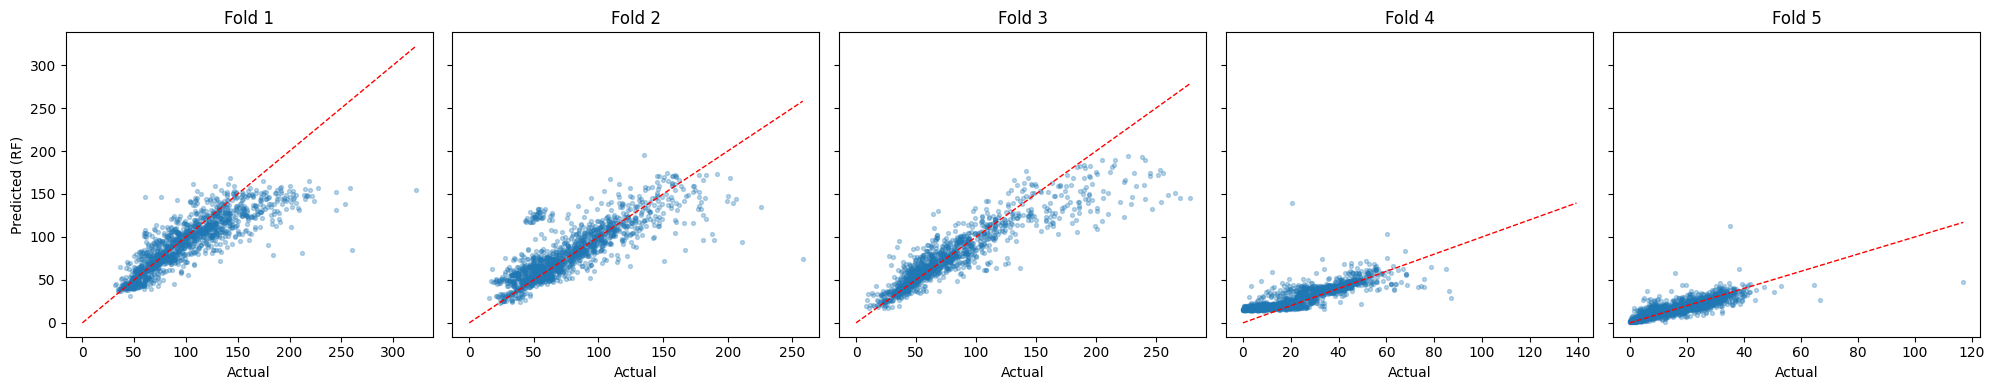

In [8]:
fig, axes = plt.subplots(1, n_splits, figsize=(20, 4), sharey=True)

for i, fold_data in enumerate(fold_predictions):
    ax = axes[i]
    ax.scatter(fold_data["y_test"], fold_data["y_pred_rf"], alpha=0.3, s=8)
    lims = [0, max(fold_data["y_test"].max(), fold_data["y_pred_rf"].max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(f"Fold {fold_data['fold']}")
    ax.set_xlabel("Actual")
    if i == 0:
        ax.set_ylabel("Predicted (RF)")

plt.tight_layout()
plt.show()

## 8. Feature importance + pm25 collinearity check

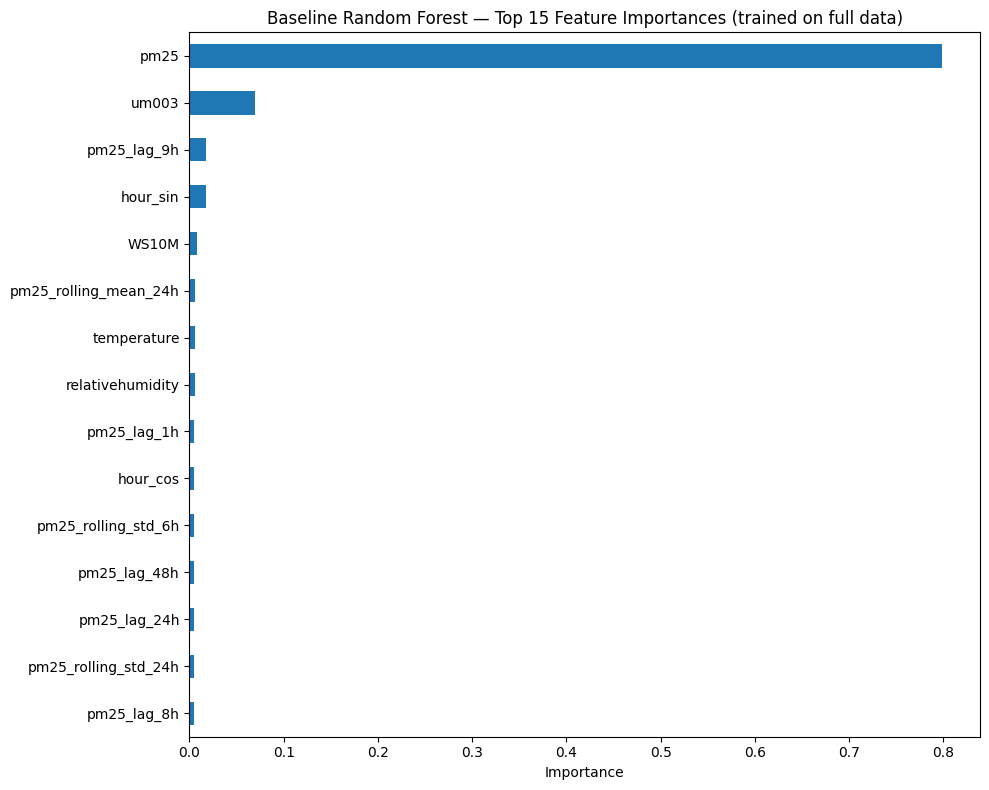

pm25                     0.798942
um003                    0.069164
pm25_lag_9h              0.017291
hour_sin                 0.017090
WS10M                    0.007939
pm25_rolling_mean_24h    0.005952
temperature              0.005906
relativehumidity         0.005346
pm25_lag_1h              0.005138
hour_cos                 0.005032
pm25_rolling_std_6h      0.004930
pm25_lag_48h             0.004803
pm25_lag_24h             0.004773
pm25_rolling_std_24h     0.004735
pm25_lag_8h              0.004568
dtype: float64


In [ ]:
#print("Correlation between pm1 and pm25:", df["pm1"].corr(df["pm25"]))

imputer_full = SimpleImputer(strategy="median")
X_full_imputed = pd.DataFrame(imputer_full.fit_transform(X), columns=X.columns, index=X.index)

final_baseline_model = RandomForestRegressor(random_state=42, n_jobs=-1)
final_baseline_model.fit(X_full_imputed, y)

importances = pd.Series(final_baseline_model.feature_importances_, index=feature_columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Baseline Random Forest — Top 15 Feature Importances (trained on full data)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(15))

## 9. Save results

In [10]:
import os
import json

os.makedirs("../models", exist_ok=True)

baseline_summary = {
    "validation": "TimeSeriesSplit (5 folds)",
    "random_forest_avg_rmse": results_df["rf_rmse"].mean(),
    "random_forest_avg_r2": results_df["rf_r2"].mean(),
    "pm25_only_avg_rmse": three_way["rmse_pm25_only"].mean(),
    "pm25_only_avg_r2": three_way["r2_pm25_only"].mean(),
    "persistence_avg_rmse": results_df["persist_rmse"].mean(),
    "persistence_avg_r2": results_df["persist_r2"].mean(),
    "linear_regression_avg_rmse": four_way["rmse_linreg"].mean(),
    "linear_regression_avg_r2": four_way["r2_linreg"].mean(),
    #"pm1_pm25_correlation": df["pm1"].corr(df["pm25"]),
    "per_fold": fold_results,
}

for fold in baseline_summary["per_fold"]:
    for key in ["test_start", "test_end"]:
        fold[key] = str(fold[key])

with open("../models/baseline_results.json", "w") as f:
    json.dump(baseline_summary, f, indent=2, default=str)

print("Saved baseline results to ../models/baseline_results.json")

Saved baseline results to ../models/baseline_results.json
